# The flow of execution inside a kernel, on one time axis

Cycle-accurate benchmarking of CUDA kernels (Core Velocity Lab's nanobenchmarking post, and the instruction
table in this repository) brackets code between two `CS2R SR_CLOCKLO` reads and reports cycles. It stops at the
SM boundary: "counters have different starting values for different SMs, so we cannot measure inter-block
execution time". This notebook goes one step further with the same two hardware timers every SM has:

- `clock64` (`CS2R SR_CLOCKLO`): one counter per SM, exact to the cycle for every warp and block on that SM;
- `%globaltimer` (`CS2R SR_GLOBALTIMERLO`): the GPU-wide ns timer, quantised to its tick.

gputrace's `ktrace` strategy runs a staged kernel in which **every warp** stamps both timers at eleven
checkpoints (entry, a calibration stamp, two dependent global loads landed, barrier arrival, barrier release, a
256-FFMA dependent chain done, a second barrier, a global store plus `__threadfence`, a grid-wide atomic ticket,
exit). The stamps stay in registers and are written at the end of the warp, so a checkpoint costs three timer
reads and nothing else: the cycle read sits between two timer reads, so the true time of cycle *c* lies in
*[g₀, g₁ + tick)* whatever happens between the reads. Within a block nothing is fitted: its warps share the SM's
cycle counter, so they compare in cycles. Across blocks, each block's 88 windows bound its own cycle-to-ns line
(the convex set of consistent rate/offset pairs, projected at every stamp), and the run's own clock bound carries
the GPU axis to the host axis, where the launch call, the mapped flag the last block writes, and the stream
synchronisation sit.

Four things the data forced, all visible in the analysis and stated with the numbers: `__syncthreads` is
`BAR.SYNC.DEFER_BLOCKING`, so a release stamp must follow a memory instruction that waits for the barrier (the
first build's release stamps sat 13 cycles after each warp's own arrival); an SM's clock is not one rate over tens
of µs or across launches, so the unit of the fit is a block, not an SM; the `%globaltimer` readings of different
warps on one SM disagree by up to ~80 ns, so every window carries a guard measured per launch as the smallest
widening that makes every block consistent; and a host whose `%globaltimer` reads 1.8 × 10¹⁸ ns needs integer
arithmetic before any float, or every difference is quantised to 256 ns.

Three checks have to hold if the placement is right, and they are evaluated on every launch: a warp's barrier
release stamp never precedes the last arrival stamp in its block (cycles, raw); the grid-wide ticket order is
consistent with the stamps across SMs (ticket k−1's atomic was issued before ticket k's returned, within the
projected bounds); the host sees the flag after the last block wrote it. Every number below is computed from the
raw records with numpy; the figures are matplotlib.

In [1]:
import os, sys, json, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Patch
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
from analysis.gputrace import Run
from analysis.ktrace import kernel_timeline, KT_NAMES, KT_PHASES, kt_stamps

C = dict(blue='#2a78d6', orange='#eb6834', aqua='#1baf7a', yellow='#eda100', magenta='#e87ba4', green='#008300', violet='#4a3aa7',
         gray='#9a9a94', ink='#15161a', grid='#e6e5e0', ink2='#55575f')
PHASE_COL = {'load': C['blue'], 'barrier1': C['orange'], 'compute': C['aqua'], 'barrier2': C['orange'], 'store_fence': C['violet'],
             'ticket': C['magenta'], 'tail': C['gray']}
mpl.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': C['ink2'], 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': C['grid'], 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': C['ink2'], 'ytick.color': C['ink2'], 'axes.labelcolor': C['ink'], 'axes.titlesize': 11,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'legend.frameon': False, 'lines.linewidth': 2})
DATA = {'A100 SXM4': os.path.join(ROOT, 'data', '2026-10-06_a100_ktrace'), 'RTX 3060': os.path.join(ROOT, 'data', '2026-10-06_3060_ktrace')}
runs = {g: Run(os.path.join(d, 'ktrace')) for g, d in DATA.items() if os.path.exists(os.path.join(d, 'ktrace.json'))}
for g, r in runs.items():
    print(f"{g}: {r.meta['sms']} SMs, tick {r.clock['tick_ns']} ns, host bound ±{r.clock['bound_ns']:.0f} ns, ffma {r.meta['ffma']}, {r.recs.size:,} stamps")

A100 SXM4: 108 SMs, tick 1024 ns, host bound ±757 ns, ffma 256, 237,600 stamps
RTX 3060: 28 SMs, tick 1024 ns, host bound ±329 ns, ffma 256, 61,600 stamps


## 1. One launch, every block, on the host axis

One block per SM (B = number of SMs), 256 threads, warp 0 of each block drawn as a bar from its entry to its exit
and coloured by phase; the other seven warps of the block are the thin lines behind it. Blocks are ordered by
their start. The host events of the same launch are the vertical lines.

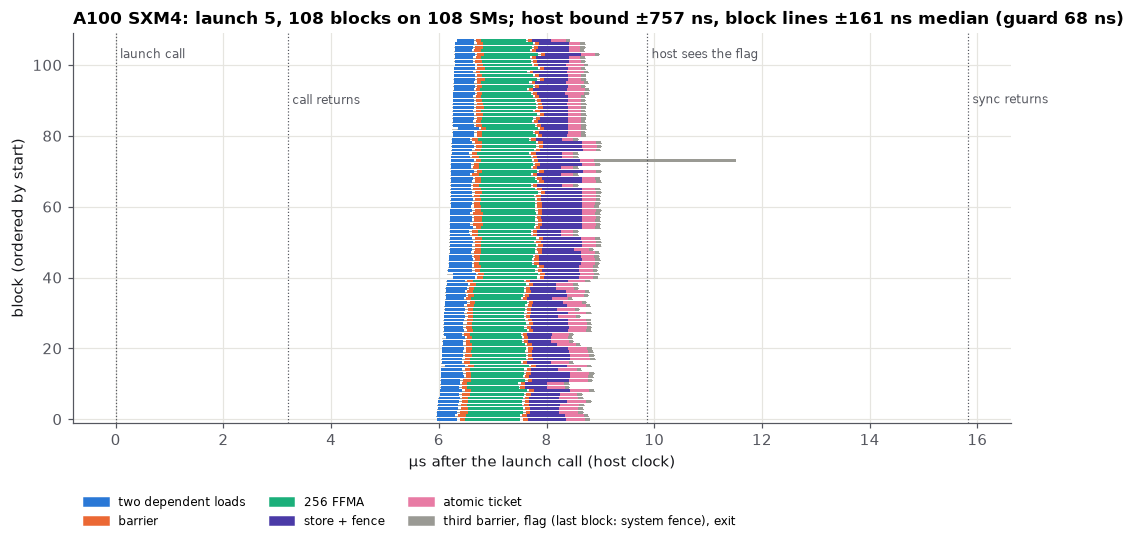

A100 SXM4: launch -> first warp 5.94 µs; block starts spread 0.39 µs; kernel span 5.57 µs; flag write -> host sees it 1.33 µs; last exit -> sync returns 4.31 µs


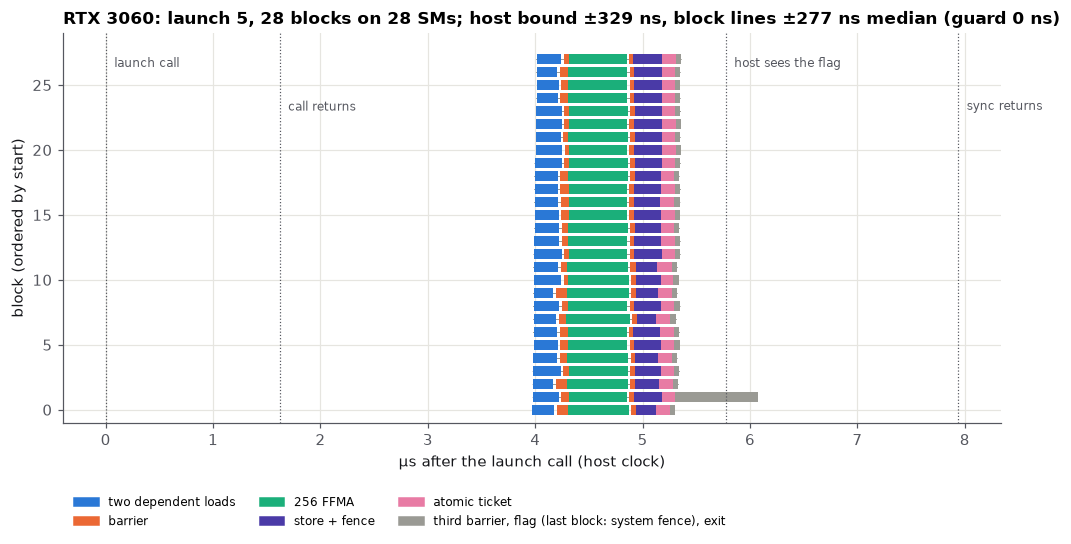

RTX 3060: launch -> first warp 3.96 µs; block starts spread 0.05 µs; kernel span 2.11 µs; flag write -> host sees it 1.18 µs; last exit -> sync returns 1.86 µs


In [2]:
def launches(run, B):
    enter = run.events('LAUNCH_ENTER')
    return [int(k) for k, a in zip(enter['kernel_id'], enter['a']) if int(a) == B]

def fig_launch(run, gname, kid, ax):
    T = kernel_timeline(run, kid); h = T['host']
    rows = T['rows']; t0 = h['launch_enter']
    us = lambda t: (t - t0) / 1e3
    blocks = {}
    for r in rows: blocks.setdefault(r['block'], []).append(r)
    order = sorted(blocks, key=lambda b: min(r['t_host'][0] for r in blocks[b]))
    for y, b in enumerate(order):
        for r in blocks[b]:
            th = r['t_host']
            if r['warp'] == 0:
                for name, i, j, _ in KT_PHASES:
                    ax.barh(y, us(th[j]) - us(th[i]), left=us(th[i]), height=0.8, color=PHASE_COL[name], lw=0)
            else:
                ax.plot([us(th[0]), us(th[10])], [y, y], color=C['gray'], lw=0.5, alpha=.5, zorder=0)
    for i, (key, lab) in enumerate((('launch_enter', 'launch call'), ('launch_return', 'call returns'), ('flag_seen', 'host sees the flag'), ('sync_return', 'sync returns'))):
        if h.get(key): ax.axvline(us(h[key]), color=C['ink2'], lw=0.8, ls=':'); ax.text(us(h[key]) + 0.08, len(order) * (0.97 - 0.12 * (i % 2)), lab, fontsize=8, va='top', ha='left', color=C['ink2'])
    ax.set_ylim(-1, len(order) + 1); ax.set_xlabel('µs after the launch call (host clock)'); ax.set_ylabel('block (ordered by start)')
    ax.set_title(f"{gname}: launch {kid}, {len(order)} blocks on {T['n_sms']} SMs; host bound ±{T['host_view']['bound_ns']:.0f} ns, block lines ±{T['sm_fit']['bound_ns_p50']:.0f} ns median (guard {T['timer_guard_ns']:.0f} ns)")
    ax.legend(handles=[Patch(color=PHASE_COL[n], label={'load': 'two dependent loads', 'barrier1': 'barrier', 'compute': '256 FFMA', 'store_fence': 'store + fence', 'ticket': 'atomic ticket', 'tail': 'third barrier, flag (last block: system fence), exit'}[n]) for n in ('load', 'barrier1', 'compute', 'store_fence', 'ticket', 'tail')],
              loc='upper left', bbox_to_anchor=(0, -0.16), ncol=3, fontsize=8)
    return T

Ts = {}
for gname, run in runs.items():
    B = run.meta['sms']; kid = launches(run, B)[-1]
    fig, ax = plt.subplots(figsize=(11, 4.6))
    Ts[gname] = fig_launch(run, gname, kid, ax)
    plt.show()
    hv = Ts[gname]['host_view']
    print(f"{gname}: launch -> first warp {hv['launch_to_first_entry_ns'] / 1e3:.2f} µs; block starts spread {Ts[gname]['block_start_spread_ns'] / 1e3:.2f} µs; "
          f"kernel span {Ts[gname]['span_gpu_ns'] / 1e3:.2f} µs; flag write -> host sees it {hv['flag_write_to_flag_seen_ns'] / 1e3:.2f} µs; last exit -> sync returns {hv['last_exit_to_sync_return_ns'] / 1e3:.2f} µs")

## 1b. What the GPU is doing at each instant: loading, waiting, computing, storing

The same launch as a stacked count: at every instant, how many of the launch's warps are between the checkpoints of
each phase (two dependent global loads in flight, waiting at a barrier for the rest of the block, running the FFMA
chain, in the global store and fence, in the atomic ticket, or in the tail). The host events are the vertical
lines, so the whole operation, from the launch call to the stream synchronisation returning, is on this one axis.
Phases are assigned from each warp's own checkpoints on the host axis (through the SM's bounded line and the run's
clock bound).

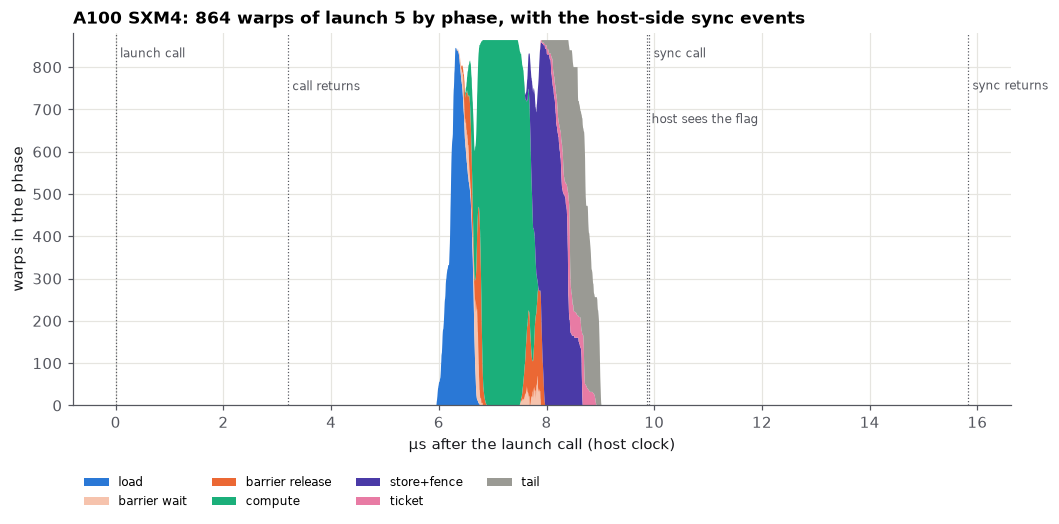

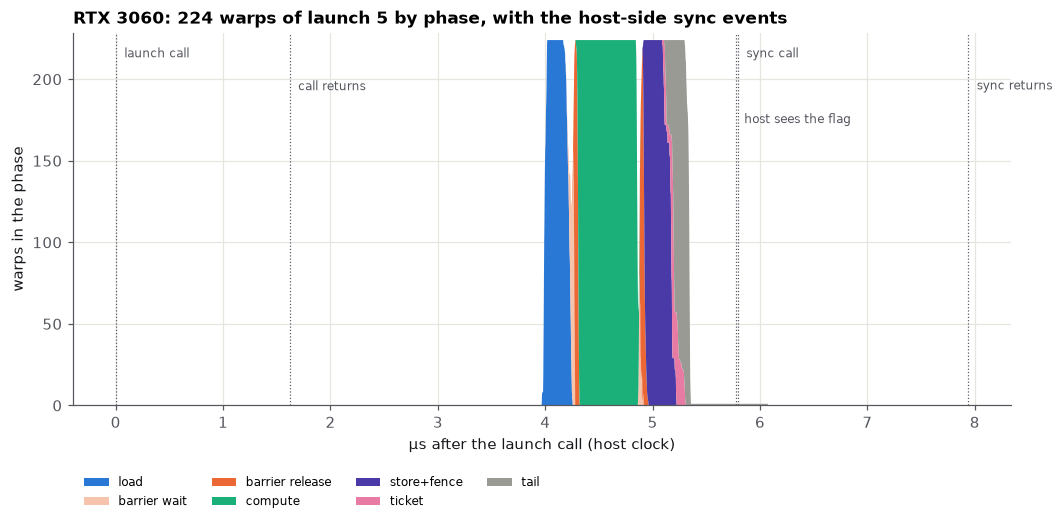

In [3]:
def fig_occupancy(T, gname, ax):
    h = T['host']; t0 = h['launch_enter']; rows = T['rows']
    us = lambda t: (t - t0) / 1e3
    # phase intervals on the host axis; the barrier phases are split into waiting (arrival .. last arrival of the block)
    # and release (last arrival .. release stamp)
    blocks = {}
    for r in rows: blocks.setdefault(r['block'], []).append(r)
    last_arr = {}
    for b, rs in blocks.items():
        for bar, ia in (('barrier1', 3), ('barrier2', 6)):
            w0 = max(rs, key=lambda r: r['c'][ia]); last_arr[(b, bar)] = w0['t_host'][ia]
    ivs = {k: [] for k in ('load', 'barrier wait', 'barrier release', 'compute', 'store+fence', 'ticket', 'tail')}
    for r in rows:
        th = r['t_host']; b = r['block']
        ivs['load'].append((th[1], th[2]))
        ivs['barrier wait'].append((th[3], last_arr[(b, 'barrier1')])); ivs['barrier release'].append((last_arr[(b, 'barrier1')], th[4]))
        ivs['compute'].append((th[4], th[5]))
        ivs['barrier wait'].append((th[6], last_arr[(b, 'barrier2')])); ivs['barrier release'].append((last_arr[(b, 'barrier2')], th[7]))
        ivs['store+fence'].append((th[7], th[8])); ivs['ticket'].append((th[8], th[9])); ivs['tail'].append((th[9], th[10]))
    tmin = min(r['t_host'][0] for r in rows); tmax = max(r['t_host'][10] for r in rows)
    grid = np.linspace(tmin - 200, tmax + 200, 1500)
    cols = {'load': PHASE_COL['load'], 'barrier wait': '#f6c3ad', 'barrier release': PHASE_COL['barrier1'], 'compute': PHASE_COL['compute'],
            'store+fence': PHASE_COL['store_fence'], 'ticket': PHASE_COL['ticket'], 'tail': PHASE_COL['tail']}
    counts = []
    for k in cols:
        iv = np.array(ivs[k]) if ivs[k] else np.zeros((0, 2))
        a = np.sort(iv[:, 0]); e = np.sort(np.maximum(iv[:, 1], iv[:, 0]))
        counts.append(np.searchsorted(a, grid, side='right') - np.searchsorted(e, grid, side='right'))
    ax.stackplot(us(grid), counts, labels=list(cols), colors=list(cols.values()), lw=0)
    for i, (key, lab) in enumerate((('launch_enter', 'launch call'), ('launch_return', 'call returns'), ('flag_seen', 'host sees the flag'), ('sync_enter', 'sync call'), ('sync_return', 'sync returns'))):
        if h.get(key): ax.axvline(us(h[key]), color=C['ink2'], lw=0.8, ls=':'); ax.text(us(h[key]) + 0.08, len(rows) * (0.98 - 0.09 * (i % 3)), lab, fontsize=8, va='top', ha='left', color=C['ink2'])
    ax.set_xlabel('µs after the launch call (host clock)'); ax.set_ylabel('warps in the phase'); ax.set_ylim(0, len(rows) * 1.02)
    ax.set_title(f'{gname}: {len(rows)} warps of launch {T["kid"]} by phase, with the host-side sync events')
    ax.legend(loc='upper left', bbox_to_anchor=(0, -0.16), fontsize=8, ncol=4)

for gname, T in Ts.items():
    fig, ax = plt.subplots(figsize=(11, 4.4)); fig_occupancy(T, gname, ax); plt.show()

## 2. Inside one block: eight warps, two barriers

Cycles since the block's first stamp, exact (one SM, one counter). Each warp's row shows its phases; the barrier
segments are split into the time the warp *waited* for the last warp to arrive (lighter) and the release
latency after the last arrival (darker). The checkpoint's own cost (checkpoint 0 → 1) has been subtracted from every phase, and the shared load + store
chain that makes the release stamp wait for the barrier (checkpoint 2 → 3) from the barrier phases.

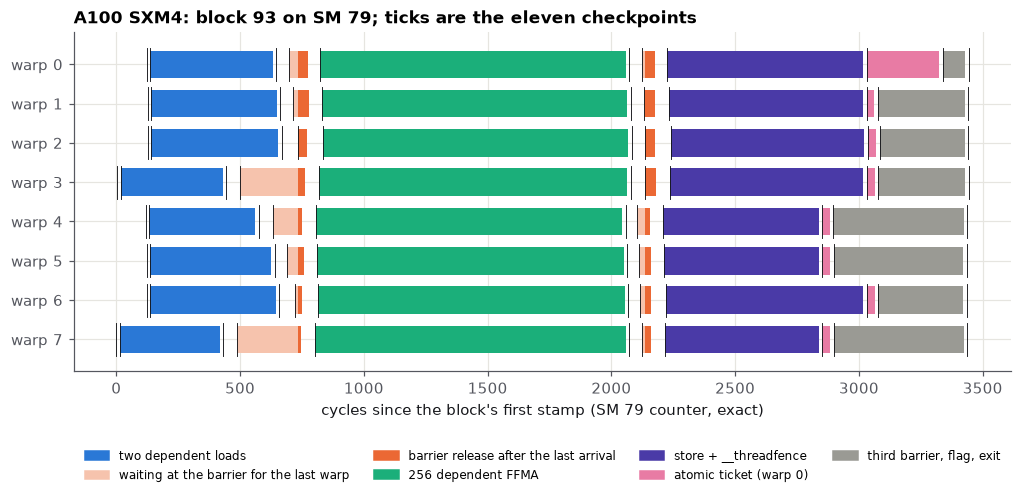

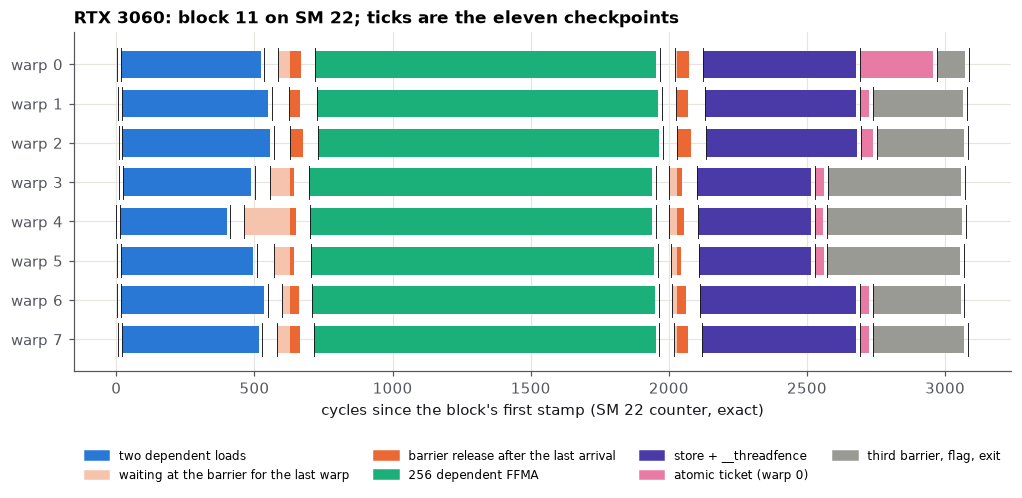

In [4]:
def fig_block(T, gname, b, ax):
    rs = sorted([r for r in T['rows'] if r['block'] == b], key=lambda r: r['warp'])
    c0 = min(r['c'][0] for r in rs); ghz = None
    last1 = max(r['c'][3] for r in rs); last2 = max(r['c'][6] for r in rs)
    for r in rs:
        y = r['warp']; c = r['c'] - c0; cal = r['cal']; touch = r['touch']
        segs = [('entry→loaded', c[1], c[2] - cal, PHASE_COL['load']),
                ('wait', c[3], last1 - c0, '#f6c3ad'), ('release', last1 - c0, c[4] - touch, PHASE_COL['barrier1']),
                ('compute', c[4], c[5] - cal, PHASE_COL['compute']),
                ('wait', c[6], last2 - c0, '#f6c3ad'), ('release', last2 - c0, c[7] - touch, PHASE_COL['barrier2']),
                ('store+fence', c[7], c[8] - cal, PHASE_COL['store_fence']), ('ticket', c[8], c[9] - cal, PHASE_COL['ticket']), ('tail', c[9], c[10] - cal, PHASE_COL['tail'])]
        for name, a, bb, col in segs:
            if bb > a: ax.barh(y, bb - a, left=a, height=0.7, color=col, lw=0)
        for k in range(11): ax.plot([c[k], c[k]], [y - 0.42, y + 0.42], color=C['ink'], lw=0.6)
    ax.set_yticks(range(len(rs))); ax.set_yticklabels([f'warp {r["warp"]}' for r in rs]); ax.invert_yaxis()
    ax.set_xlabel(f'cycles since the block\'s first stamp (SM {rs[0]["sm"]} counter, exact)')
    ax.set_title(f"{gname}: block {b} on SM {rs[0]['sm']}; ticks are the eleven checkpoints")
    ax.legend(handles=[Patch(color=PHASE_COL['load'], label='two dependent loads'), Patch(color='#f6c3ad', label='waiting at the barrier for the last warp'),
                       Patch(color=PHASE_COL['barrier1'], label='barrier release after the last arrival'), Patch(color=PHASE_COL['compute'], label='256 dependent FFMA'),
                       Patch(color=PHASE_COL['store_fence'], label='store + __threadfence'), Patch(color=PHASE_COL['ticket'], label='atomic ticket (warp 0)'), Patch(color=PHASE_COL['tail'], label='third barrier, flag, exit')],
              loc='upper left', bbox_to_anchor=(0, -0.2), ncol=4, fontsize=8)

for gname, T in Ts.items():
    b = max({r['block'] for r in T['rows']} , key=lambda b: max(x['arrival_spread'] for x in T['barriers'] if x['block'] == b))
    fig, ax = plt.subplots(figsize=(11, 4)); fig_block(T, gname, b, ax); plt.show()

## 3. Phase costs across all launches: one block per SM against four

Cycles per phase over every warp of every launch, for B = SMs (each block alone on its SM) and B = 4 × SMs
(four blocks, 32 warps, share each SM). The barrier is split into wait and release; the compute chain is the
same 256 dependent FFMA either way, so what moves is contention for the SM.

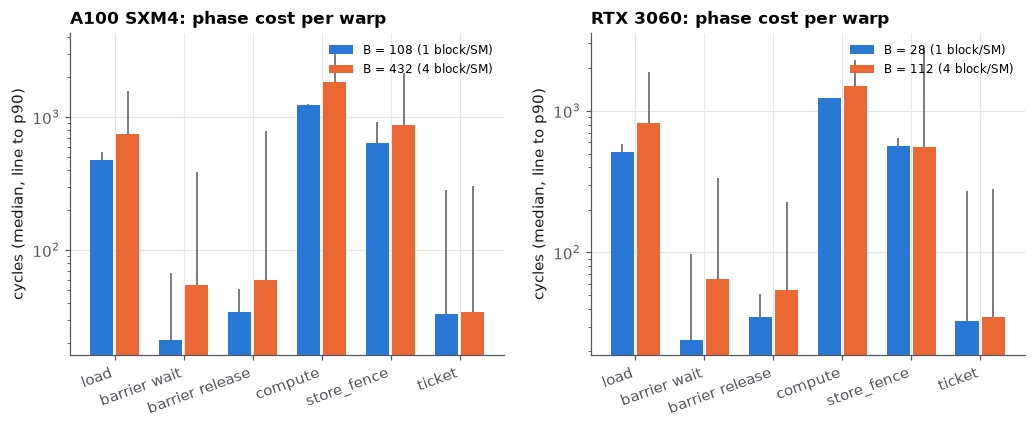

A100 SXM4 B=108: checkpoint cost 14 cy | load 479 | barrier wait 21 (p99 174) release 34 | compute 1238 | store+fence 644 | ticket 33 cy; SM clock 1.350 GHz; span 5.8 µs
A100 SXM4 B=432: checkpoint cost 15 cy | load 742 | barrier wait 55 (p99 1972) release 60 | compute 1846 | store+fence 873 | ticket 34 cy; SM clock 1.347 GHz; span 15.0 µs
RTX 3060 B=28: checkpoint cost 14 cy | load 512 | barrier wait 24 (p99 155) release 35 | compute 1237 | store+fence 569 | ticket 33 cy; SM clock 1.708 GHz; span 3.2 µs
RTX 3060 B=112: checkpoint cost 16 cy | load 821 | barrier wait 65 (p99 874) release 54 | compute 1488 | store+fence 559 | ticket 35 cy; SM clock 1.821 GHz; span 8.4 µs


In [5]:
from analysis.ktrace import a_ktrace
res = {g: a_ktrace(run) for g, run in runs.items()}
order = ['load', 'barrier wait', 'barrier release', 'compute', 'store_fence', 'ticket']
fig, axes = plt.subplots(1, len(runs), figsize=(5.6 * len(runs), 3.8), squeeze=False)
for ax, (gname, R) in zip(axes[0], res.items()):
    Bs = sorted(R['by_blocks'])
    w = 0.38
    for k, B in enumerate(Bs[:2]):
        d = R['by_blocks'][B]
        vals = [d['phases_cycles']['load'], d['barrier_wait_cycles'], d['barrier_latency_cycles'], d['phases_cycles']['compute'], d['phases_cycles']['store_fence'], d['phases_cycles']['ticket']]
        x = np.arange(len(order)) + (k - 0.5) * w
        med = np.array([v['p50'] for v in vals]); p90 = np.array([v['p90'] for v in vals])
        ax.bar(x, med, width=w - 0.04, color=[C['blue'], C['orange']][k], label=f'B = {B} ({B // runs[gname].meta["sms"]} block/SM)', lw=0)
        ax.vlines(x, med, p90, color=C['ink2'], lw=1)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=20, ha='right'); ax.set_yscale('log'); ax.set_ylabel('cycles (median, line to p90)')
    ax.set_title(f'{gname}: phase cost per warp'); ax.legend(fontsize=8)
plt.show()
for gname, R in res.items():
    for B, d in sorted(R['by_blocks'].items()):
        ph = d['phases_cycles']
        print(f"{gname} B={B}: checkpoint cost {d['checkpoint_cost_cycles']['p50']:.0f} cy | load {ph['load']['p50']:.0f} | barrier wait {d['barrier_wait_cycles']['p50']:.0f} (p99 {d['barrier_wait_cycles']['p99']:.0f}) "
              f"release {d['barrier_latency_cycles']['p50']:.0f} | compute {ph['compute']['p50']:.0f} | store+fence {ph['store_fence']['p50']:.0f} | ticket {ph['ticket']['p50']:.0f} cy; "
              f"SM clock {d['sm_ghz']['p50']:.3f} GHz; span {d['kernel_span_ns']['p50'] / 1e3:.1f} µs")

## 4. Who waits for whom at the first barrier

Per block (rows) and warp (columns): cycles the warp waited at the first barrier for the last warp of its block
to arrive, one launch with one block per SM. A column that is consistently dark is a warp that is consistently
late; a flat row is a block whose warps arrived together.

A100 SXM4: warps released before the last arrival: 0 (must be 0); arrival spread p50 101 cy, max 244 cy
RTX 3060: warps released before the last arrival: 0 (must be 0); arrival spread p50 126 cy, max 164 cy


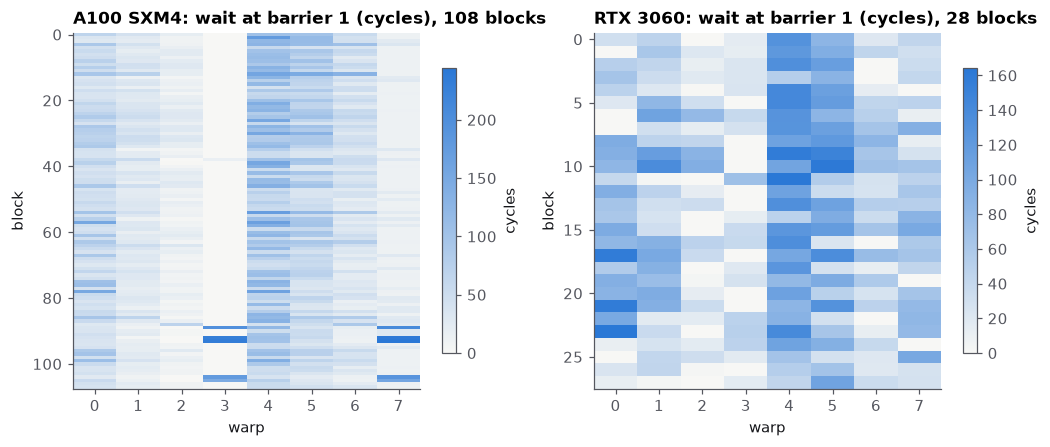

In [6]:
fig, axes = plt.subplots(1, len(Ts), figsize=(5.6 * len(Ts), 4.2), squeeze=False)
for ax, (gname, T) in zip(axes[0], Ts.items()):
    bars = [b for b in T['barriers'] if b['barrier'] == 'barrier1']
    M = np.array([b['wait_per_warp'] for b in bars])
    im = ax.imshow(M, aspect='auto', cmap=mpl.colors.LinearSegmentedColormap.from_list('b', ['#f7f7f5', C['blue']]), interpolation='nearest')
    ax.grid(False); ax.set_xlabel('warp'); ax.set_ylabel('block'); ax.set_xticks(range(M.shape[1]))
    ax.set_title(f'{gname}: wait at barrier 1 (cycles), {M.shape[0]} blocks')
    plt.colorbar(im, ax=ax, shrink=0.8, label='cycles')
    early = sum(b['release_before_last_arrival'] for b in T['barriers'])
    print(f"{gname}: warps released before the last arrival: {early} (must be 0); arrival spread p50 {np.median([b['arrival_spread'] for b in bars]):.0f} cy, max {max(b['arrival_spread'] for b in bars):.0f} cy")
plt.show()

## 5. How precise is the placement, and does it pass its checks

Per block, the half-width of the projected feasible region at its stamps (the bound on any cross-block time) against
the timer tick, including the per-launch timer guard; the SM clocks the lines allow; and the ticket check: ticket
*k*'s atomic cannot have returned before ticket *k−1*'s was issued, within the two blocks' bounds.

A100 SXM4: block-line half-width p50 198 ns, max 560 ns (tick 1024 ns); SM clock 1.349 GHz; ticket slack min -127 ns over 2690 consecutive tickets


RTX 3060: block-line half-width p50 178 ns, max 362 ns (tick 1024 ns); SM clock 1.779 GHz; ticket slack min -87 ns over 690 consecutive tickets


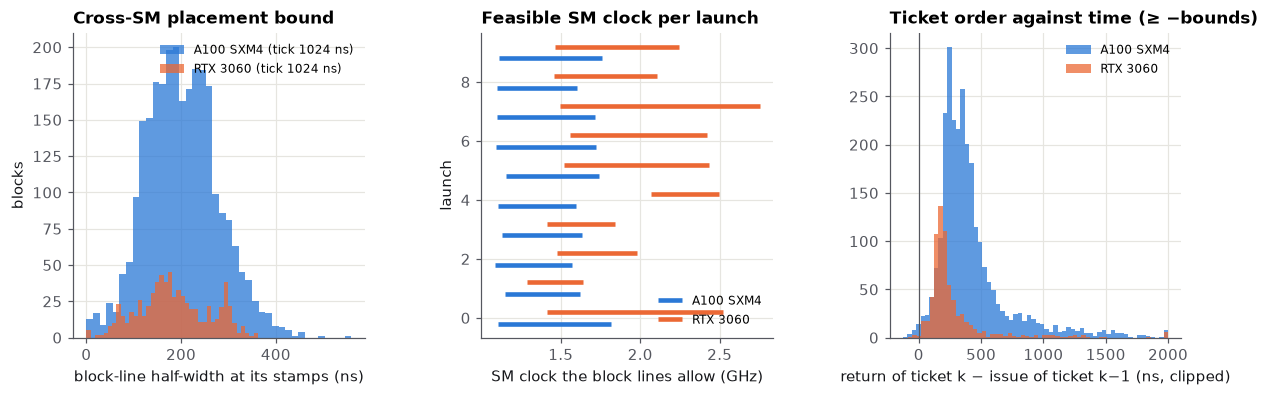

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw=dict(wspace=0.4))
for gname, run in runs.items():
    col = C['blue'] if gname.startswith('A100') else C['orange']
    bounds, ghz, slack, rng = [], [], [], []
    for kid in sorted(set(kt_stamps(run)['kid'].tolist())):
        T = kernel_timeline(run, kid)
        bounds += [r['bound_ns'] for r in T['rows'] if r['warp'] == 0]
        ghz += [T['sm_fit']['ghz_p50']]; rng.append((T['sm_fit']['ghz_min'], T['sm_fit']['ghz_max'], T['span_gpu_ns'] / 1e3))
        tk = sorted([(r['ticket'], r['t_gpu'][8], r['t_gpu'][9]) for r in T['rows'] if r['warp'] == 0 and r['ticket'] is not None])
        slack += [t9 - t8 for (_, t8, _), (_, _, t9) in zip(tk, tk[1:])]
        if T['ticket']['violations']: print(f'{gname} launch {kid}: {T["ticket"]["violations"]} ticket-order violations')
    tick = run.clock['tick_ns']
    axes[0].hist(bounds, bins=40, color=col, alpha=.75, label=f'{gname} (tick {tick} ns)', lw=0)
    for i, (lo, hi, span) in enumerate(rng):
        y = i + (0.2 if gname.startswith('RTX') else -0.2)
        axes[1].plot([lo, hi], [y, y], color=col, lw=3, solid_capstyle='butt', label=gname if i == 0 else None)
    axes[2].hist(np.clip(slack, -200, 2000), bins=60, color=col, alpha=.75, label=gname, lw=0)
    print(f"{gname}: block-line half-width p50 {np.median(bounds):.0f} ns, max {max(bounds):.0f} ns (tick {tick} ns); SM clock {np.median(ghz):.3f} GHz; "
          f"ticket slack min {min(slack):.0f} ns over {len(slack)} consecutive tickets")
axes[0].set_xlabel('block-line half-width at its stamps (ns)'); axes[0].set_ylabel('blocks'); axes[0].set_title('Cross-SM placement bound'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('SM clock the block lines allow (GHz)'); axes[1].set_ylabel('launch'); axes[1].set_title('Feasible SM clock per launch'); axes[1].legend(fontsize=8)
axes[2].set_xlabel('return of ticket k − issue of ticket k−1 (ns, clipped)'); axes[2].set_title('Ticket order against time (≥ −bounds)'); axes[2].axvline(0, color=C['ink2'], lw=0.8); axes[2].legend(fontsize=8)
plt.show()

## 6. What each phase is, in SASS

The instructions between consecutive checkpoints of the compiled kernel (sm_80 build; the sm_86 build differs
only in the FFMA loop body). The checkpoint reads themselves are excluded. The phase named *tail* holds the third
`__syncthreads` and the last block's flag write.

In [8]:
for gname, d in DATA.items():
    p = os.path.join(d, 'ktrace_phases.json')
    if not os.path.exists(p): continue
    ph = json.load(open(p))['phases']
    print(f'== {gname}')
    for name, x in ph.items():
        ops = ', '.join(f'{k}×{v}' if v > 1 else k for k, v in sorted(x['opcodes'].items(), key=lambda kv: -kv[1]))
        print(f'  {name:28s} {x["n"]:3d} instructions: {ops}')

== A100 SXM4
  entry -> cal                   0 instructions: 
  cal -> loaded                 12 instructions: S2R×2, IMAD.WIDE.U32×2, IMAD.MOV.U32, IMAD, LDG.E.CONSTANT, LOP3.LUT, IMAD.IADD, LDG.E.128.CONSTANT, SHF.L.U32, STS.128
  loaded -> bar1_arrive          2 instructions: LDS.128, STS.128
  bar1_arrive -> bar1_release    5 instructions: BAR.SYNC.DEFER_BLOCKING, IADD3, LOP3.LUT, LDS.128, STS.128
  bar1_release -> computed      36 instructions: FFMA×17, BRA×5, ISETP.NE.AND×4, IADD3×4, IMAD.MOV.U32×2, FADD, LOP3.LUT, ISETP.GE.U32.AND, HFMA2.MMA
  computed -> bar2_arrive        2 instructions: LDS.128, STS.128
  bar2_arrive -> bar2_release    5 instructions: BAR.SYNC.DEFER_BLOCKING, IADD3, LOP3.LUT, LDS.128, STS.128
  bar2_release -> stored         7 instructions: LEA, IMAD.MOV.U32, LEA.HI.X, STG.E.128, MEMBAR.SC.GPU, ERRBAR, CCTL.IVALL
  stored -> ticket               9 instructions: IMAD.MOV.U32×2, ISETP.NE.AND, BSSY, BRA, MOV, ATOMG.E.ADD.STRONG.GPU, STS, BSYNC
  ticket -> exit 

## What this establishes

Every warp of a running kernel can be placed on one time axis from entry to exit, with its loads, barriers,
compute, store, fence and atomic as measured segments: exact cycles within a block, and across blocks a bound of
about a hundred to a few hundred ns from a 1024 ns tick (median half-width in the printouts above), carried to
the host axis by the run's clock bound. The barrier check (0 early releases on every launch), the ticket check
(0 violations) and the flag check hold on every launch, so the placement is tested rather than assumed; the
checks also caught the deferred barrier, the per-SM clock modulation and the timer read skew that would otherwise
have been reported as results. The next step on this axis is a second GPU (the per-GPU half is already in `gpus`/`nccl`), then a second
host.